# DINOv2 vs CNN: Transfer Learning vs Training from Scratch

This notebook compares two approaches for binary image classification:

1. **Fine-tuning DINOv2**: Using Meta's self-supervised vision transformer
2. **Training from Scratch**: Building a CNN classifier from the ground up

We'll examine:
- Training time and convergence differences
- Data efficiency with limited samples
- Final performance comparison
- Parameter efficiency

## What is DINOv2?

DINOv2 is Meta's self-supervised vision transformer that learns robust visual representations without labels. Key features:

- **Self-supervised learning**: Trained on millions of images without human annotations
- **Strong representations**: Captures semantic and geometric features
- **Transfer learning**: Excellent for fine-tuning on downstream tasks

## Setup and Installation

In [4]:
# Install required packages
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])

packages = ["torch", "torchvision", "transformers", "datasets", "pillow", "matplotlib", "seaborn", "scikit-learn"]

for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        install_package(package)

print("All packages installed successfully!")

Installing pillow...



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


Installing scikit-learn...
All packages installed successfully!



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [5]:
# Core imports
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

In [6]:
# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset

# Transformers and datasets
from transformers import AutoImageProcessor, AutoModel
from datasets import load_dataset

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Dataset Loading

In [8]:
# Load the Beans dataset
print("Loading Beans dataset from Hugging Face...")

try:
    dataset = load_dataset("beans")
    print("Dataset loaded successfully!")
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise

print(f"Train samples: {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"Test samples: {len(dataset['test'])}")

Loading Beans dataset from Hugging Face...
Dataset loaded successfully!
Train samples: 1034
Validation samples: 133
Test samples: 128


In [9]:
# Convert to binary classification
class_names = dataset['train'].features['labels'].names
print(f"Original classes: {class_names}")

def convert_to_binary(example):
    # 0 = healthy, 1,2 = diseased
    example['labels'] = 0 if example['labels'] == 0 else 1
    return example

dataset = dataset.map(convert_to_binary)

# Check distribution
train_labels = dataset['train']['labels']
healthy_count = train_labels.count(0)
diseased_count = train_labels.count(1)

print(f"\nBinary classification:")
print(f"Healthy: {healthy_count} samples ({healthy_count/len(train_labels)*100:.1f}%)")
print(f"Diseased: {diseased_count} samples ({diseased_count/len(train_labels)*100:.1f}%)")

Original classes: ['angular_leaf_spot', 'bean_rust', 'healthy']

Binary classification:
Healthy: 345 samples (33.4%)
Diseased: 689 samples (66.6%)


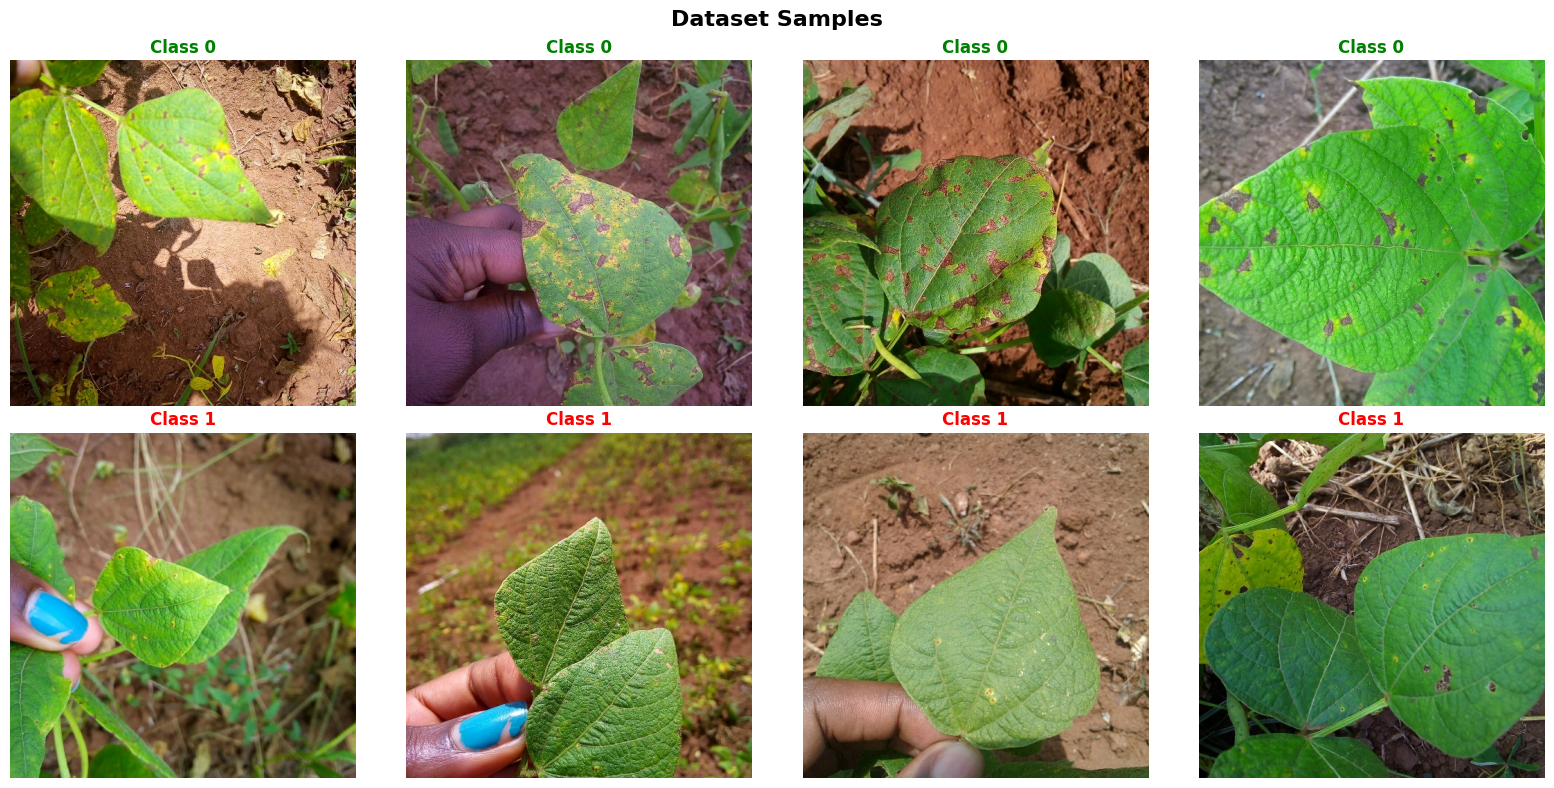

Image size: (500, 500), Mode: RGB


In [10]:
# Visualize sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Dataset Samples', fontsize=16, fontweight='bold')

# Get samples for each class
healthy_samples = [item for item in dataset['train'] if item['labels'] == 0][:4]
diseased_samples = [item for item in dataset['train'] if item['labels'] == 1][:4]

# Plot samples
for i, sample in enumerate(healthy_samples):
    axes[0, i].imshow(sample['image'])
    axes[0, i].set_title('Class 0', fontweight='bold', color='green')
    axes[0, i].axis('off')

for i, sample in enumerate(diseased_samples):
    axes[1, i].imshow(sample['image'])
    axes[1, i].set_title('Class 1', fontweight='bold', color='red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Print image info
sample_img = dataset['train'][0]['image']
print(f"Image size: {sample_img.size}, Mode: {sample_img.mode}")

## Data Preprocessing

In [11]:
class ImageDataset(Dataset):
    def __init__(self, hf_dataset, processor=None, transform=None):
        self.dataset = hf_dataset
        self.processor = processor
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image'].convert('RGB')
        label = item['labels']
        
        if self.processor:
            # For DINOv2
            inputs = self.processor(image, return_tensors="pt")
            pixel_values = inputs['pixel_values'].squeeze(0)
            return pixel_values, torch.tensor(label, dtype=torch.long)
        
        elif self.transform:
            # For CNN
            image = self.transform(image)
            return image, torch.tensor(label, dtype=torch.long)
        
        else:
            return image, torch.tensor(label, dtype=torch.long)

In [12]:
# Load DINOv2 processor
print("Loading DINOv2 processor...")
dinov2_processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
print("DINOv2 processor loaded!")

Loading DINOv2 processor...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


DINOv2 processor loaded!


In [13]:
# CNN transforms
cnn_transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

cnn_transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [14]:
# Create datasets
dinov2_train_dataset = ImageDataset(dataset['train'], processor=dinov2_processor)
dinov2_val_dataset = ImageDataset(dataset['validation'], processor=dinov2_processor)
dinov2_test_dataset = ImageDataset(dataset['test'], processor=dinov2_processor)

cnn_train_dataset = ImageDataset(dataset['train'], transform=cnn_transform_train)
cnn_val_dataset = ImageDataset(dataset['validation'], transform=cnn_transform_val)
cnn_test_dataset = ImageDataset(dataset['test'], transform=cnn_transform_val)

print(f"Datasets created!")
print(f"Train: {len(dinov2_train_dataset)}, Val: {len(dinov2_val_dataset)}, Test: {len(dinov2_test_dataset)}")

Datasets created!
Train: 1034, Val: 133, Test: 128


In [15]:
# Create data loaders
batch_size = 16

dinov2_train_loader = DataLoader(dinov2_train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
dinov2_val_loader = DataLoader(dinov2_val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
dinov2_test_loader = DataLoader(dinov2_test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
cnn_val_loader = DataLoader(cnn_val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
cnn_test_loader = DataLoader(cnn_test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Data loaders created!")

Data loaders created!


## Model Definitions

In [16]:
class DINOv2Classifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = AutoModel.from_pretrained('facebook/dinov2-base')
        
        # Classification head
        hidden_size = self.backbone.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        # Use [CLS] token
        pooled_output = outputs.last_hidden_state[:, 0]
        logits = self.classifier(pooled_output)
        return logits

In [17]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [18]:
# Initialize models
print("Initializing models...")
dinov2_model = DINOv2Classifier(num_classes=2).to(device)
cnn_model = SimpleCNN(num_classes=2).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

dinov2_params = count_parameters(dinov2_model)
cnn_params = count_parameters(cnn_model)

print(f"DINOv2 parameters: {dinov2_params:,}")
print(f"CNN parameters: {cnn_params:,}")
print(f"Parameter ratio: {dinov2_params/cnn_params:.1f}x")

Initializing models...
DINOv2 parameters: 86,679,170
CNN parameters: 6,813,442
Parameter ratio: 12.7x


## Training Utilities

In [19]:
def evaluate_model(model, data_loader, criterion, device):
    """Evaluate model on given data loader"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    avg_loss = total_loss / len(data_loader)
    
    return avg_loss, accuracy, all_preds, all_labels

In [20]:
def train_model(model, train_loader, val_loader, num_epochs, learning_rate, model_name):
    """Train model and return history"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'epochs': []
    }
    
    best_val_acc = 0
    start_time = time.time()
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        # Calculate training metrics
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        
        # Validation phase
        val_loss, val_acc, _, _ = evaluate_model(model, val_loader, criterion, device)
        
        # Record metrics
        history['epochs'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name.lower()}_model.pth')
        
        print(f'{model_name} Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    total_time = time.time() - start_time
    print(f'{model_name} training completed in {total_time:.1f}s')
    print(f'Best validation accuracy: {best_val_acc:.2f}%')
    
    return history, best_val_acc, total_time

## Train DINOv2 Model

In [21]:
# Training hyperparameters for DINOv2
dinov2_epochs = 8
dinov2_lr = 1e-4

print("=" * 50)
print("TRAINING DINOV2 MODEL")
print("=" * 50)

TRAINING DINOV2 MODEL


In [22]:
dinov2_history, dinov2_best_acc, dinov2_time = train_model(
    dinov2_model, 
    dinov2_train_loader, 
    dinov2_val_loader, 
    dinov2_epochs, 
    dinov2_lr, 
    "DINOv2"
)

DINOv2 Epoch 1/8: Train Loss: 0.6669, Train Acc: 64.70%, Val Loss: 0.6230, Val Acc: 66.92%
DINOv2 Epoch 2/8: Train Loss: 0.6171, Train Acc: 67.70%, Val Loss: 0.6845, Val Acc: 66.92%
DINOv2 Epoch 3/8: Train Loss: 0.6313, Train Acc: 66.54%, Val Loss: 0.5085, Val Acc: 78.95%
DINOv2 Epoch 4/8: Train Loss: 0.5399, Train Acc: 73.79%, Val Loss: 0.4846, Val Acc: 75.19%
DINOv2 Epoch 5/8: Train Loss: 0.4930, Train Acc: 76.98%, Val Loss: 0.3715, Val Acc: 84.21%
DINOv2 Epoch 6/8: Train Loss: 0.5066, Train Acc: 76.21%, Val Loss: 0.4159, Val Acc: 78.20%
DINOv2 Epoch 7/8: Train Loss: 0.3785, Train Acc: 83.27%, Val Loss: 0.3779, Val Acc: 78.95%
DINOv2 Epoch 8/8: Train Loss: 0.3728, Train Acc: 83.46%, Val Loss: 0.3294, Val Acc: 84.21%
DINOv2 training completed in 1312.2s
Best validation accuracy: 84.21%


## Train CNN from Scratch

In [23]:
# Training hyperparameters for CNN
cnn_epochs = 15
cnn_lr = 1e-3

print("=" * 50)
print("TRAINING CNN FROM SCRATCH")
print("=" * 50)

TRAINING CNN FROM SCRATCH


In [24]:
cnn_history, cnn_best_acc, cnn_time = train_model(
    cnn_model, 
    cnn_train_loader, 
    cnn_val_loader, 
    cnn_epochs, 
    cnn_lr, 
    "CNN"
)

CNN Epoch 1/15: Train Loss: 1.4096, Train Acc: 67.70%, Val Loss: 0.4310, Val Acc: 77.44%
CNN Epoch 2/15: Train Loss: 0.5493, Train Acc: 75.34%, Val Loss: 0.3813, Val Acc: 83.46%
CNN Epoch 3/15: Train Loss: 0.4842, Train Acc: 79.40%, Val Loss: 0.3356, Val Acc: 85.71%
CNN Epoch 4/15: Train Loss: 0.4189, Train Acc: 82.11%, Val Loss: 0.3610, Val Acc: 83.46%
CNN Epoch 5/15: Train Loss: 0.4509, Train Acc: 79.50%, Val Loss: 0.3731, Val Acc: 87.22%
CNN Epoch 6/15: Train Loss: 0.4287, Train Acc: 81.72%, Val Loss: 0.4429, Val Acc: 80.45%
CNN Epoch 7/15: Train Loss: 0.4027, Train Acc: 81.72%, Val Loss: 0.3329, Val Acc: 84.21%
CNN Epoch 8/15: Train Loss: 0.4384, Train Acc: 80.95%, Val Loss: 0.3350, Val Acc: 84.21%
CNN Epoch 9/15: Train Loss: 0.3988, Train Acc: 82.40%, Val Loss: 0.2840, Val Acc: 87.22%
CNN Epoch 10/15: Train Loss: 0.3579, Train Acc: 84.43%, Val Loss: 0.2711, Val Acc: 90.23%
CNN Epoch 11/15: Train Loss: 0.3154, Train Acc: 86.27%, Val Loss: 0.6922, Val Acc: 72.18%
CNN Epoch 12/15: Tr

## Training Comparison

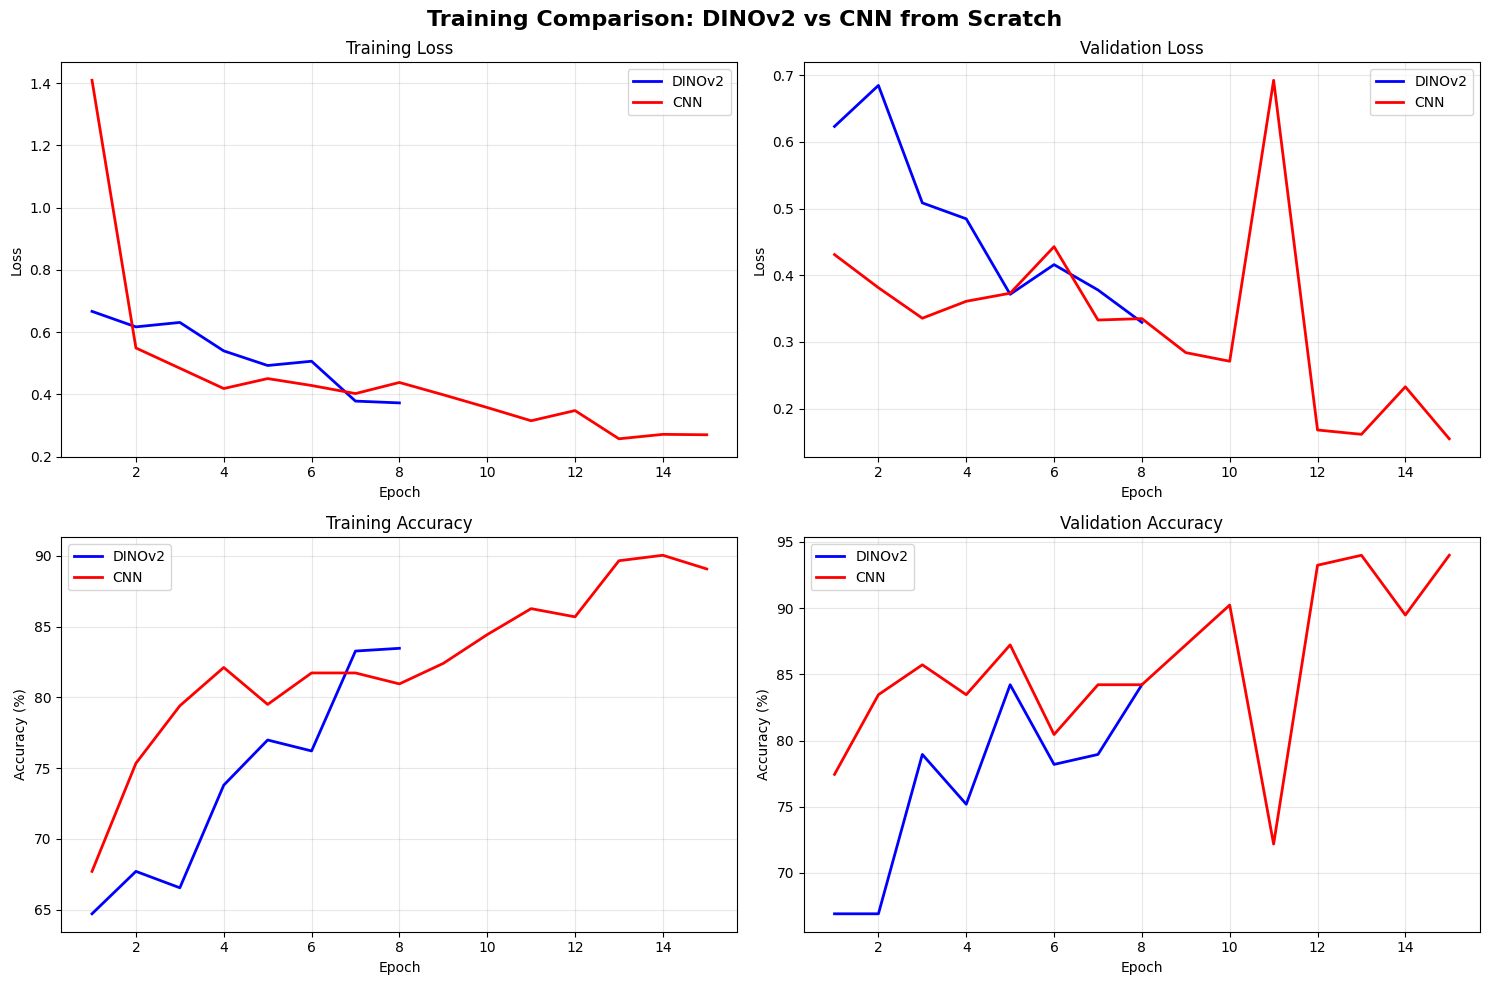

In [25]:
# Plot training comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Training Comparison: DINOv2 vs CNN from Scratch', fontsize=16, fontweight='bold')

# Training Loss
axes[0, 0].plot(dinov2_history['epochs'], dinov2_history['train_loss'], 'b-', label='DINOv2', linewidth=2)
axes[0, 0].plot(cnn_history['epochs'], cnn_history['train_loss'], 'r-', label='CNN', linewidth=2)
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation Loss
axes[0, 1].plot(dinov2_history['epochs'], dinov2_history['val_loss'], 'b-', label='DINOv2', linewidth=2)
axes[0, 1].plot(cnn_history['epochs'], cnn_history['val_loss'], 'r-', label='CNN', linewidth=2)
axes[0, 1].set_title('Validation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training Accuracy
axes[1, 0].plot(dinov2_history['epochs'], dinov2_history['train_acc'], 'b-', label='DINOv2', linewidth=2)
axes[1, 0].plot(cnn_history['epochs'], cnn_history['train_acc'], 'r-', label='CNN', linewidth=2)
axes[1, 0].set_title('Training Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Validation Accuracy
axes[1, 1].plot(dinov2_history['epochs'], dinov2_history['val_acc'], 'b-', label='DINOv2', linewidth=2)
axes[1, 1].plot(cnn_history['epochs'], cnn_history['val_acc'], 'r-', label='CNN', linewidth=2)
axes[1, 1].set_title('Validation Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Training summary
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"DINOv2 - Best Val Accuracy: {dinov2_best_acc:.2f}% in {dinov2_time:.1f}s ({dinov2_epochs} epochs)")
print(f"CNN    - Best Val Accuracy: {cnn_best_acc:.2f}% in {cnn_time:.1f}s ({cnn_epochs} epochs)")
print(f"\nTime per epoch:")
print(f"DINOv2: {dinov2_time/dinov2_epochs:.1f}s/epoch")
print(f"CNN:    {cnn_time/cnn_epochs:.1f}s/epoch")


TRAINING SUMMARY
DINOv2 - Best Val Accuracy: 84.21% in 1312.2s (8 epochs)
CNN    - Best Val Accuracy: 93.98% in 534.2s (15 epochs)

Time per epoch:
DINOv2: 164.0s/epoch
CNN:    35.6s/epoch


## Test Set Evaluation

In [27]:
# Load best models
dinov2_model.load_state_dict(torch.load('best_dinov2_model.pth'))
cnn_model.load_state_dict(torch.load('best_cnn_model.pth'))

criterion = nn.CrossEntropyLoss()
print("Best models loaded!")

Best models loaded!


In [28]:
# Evaluate both models on test set
dinov2_test_loss, dinov2_test_acc, dinov2_preds, dinov2_labels = evaluate_model(
    dinov2_model, dinov2_test_loader, criterion, device
)

cnn_test_loss, cnn_test_acc, cnn_preds, cnn_labels = evaluate_model(
    cnn_model, cnn_test_loader, criterion, device
)

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
print(f"DINOv2 - Test Accuracy: {dinov2_test_acc:.2f}%, Test Loss: {dinov2_test_loss:.4f}")
print(f"CNN    - Test Accuracy: {cnn_test_acc:.2f}%, Test Loss: {cnn_test_loss:.4f}")


TEST SET EVALUATION
DINOv2 - Test Accuracy: 83.59%, Test Loss: 0.3800
CNN    - Test Accuracy: 91.41%, Test Loss: 0.2076


In [29]:
# Classification reports
class_names_binary = ['Class 0', 'Class 1']

print("\nDINOv2 Classification Report:")
print(classification_report(dinov2_labels, dinov2_preds, target_names=class_names_binary))

print("\nCNN Classification Report:")
print(classification_report(cnn_labels, cnn_preds, target_names=class_names_binary))


DINOv2 Classification Report:
              precision    recall  f1-score   support

     Class 0       0.76      0.74      0.75        43
     Class 1       0.87      0.88      0.88        85

    accuracy                           0.84       128
   macro avg       0.82      0.81      0.82       128
weighted avg       0.84      0.84      0.84       128


CNN Classification Report:
              precision    recall  f1-score   support

     Class 0       0.86      0.88      0.87        43
     Class 1       0.94      0.93      0.93        85

    accuracy                           0.91       128
   macro avg       0.90      0.91      0.90       128
weighted avg       0.91      0.91      0.91       128



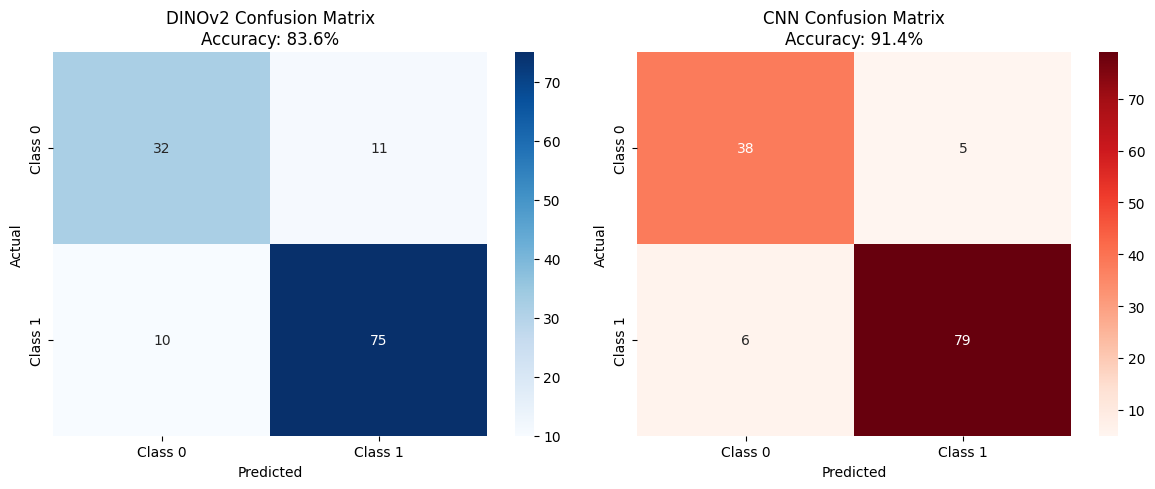

In [30]:
# Create confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# DINOv2 confusion matrix
dinov2_cm = confusion_matrix(dinov2_labels, dinov2_preds)
sns.heatmap(dinov2_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_binary, yticklabels=class_names_binary, ax=axes[0])
axes[0].set_title(f'DINOv2 Confusion Matrix\nAccuracy: {dinov2_test_acc:.1f}%')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# CNN confusion matrix
cnn_cm = confusion_matrix(cnn_labels, cnn_preds)
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names_binary, yticklabels=class_names_binary, ax=axes[1])
axes[1].set_title(f'CNN Confusion Matrix\nAccuracy: {cnn_test_acc:.1f}%')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Final Comparison Summary

In [31]:
# Create comparison table
comparison_data = {
    'Metric': [
        'Model Parameters',
        'Training Epochs',
        'Learning Rate',
        'Total Training Time (s)',
        'Time per Epoch (s)',
        'Best Validation Accuracy (%)',
        'Test Accuracy (%)',
        'Test Loss'
    ],
    'DINOv2': [
        f'{dinov2_params:,}',
        dinov2_epochs,
        dinov2_lr,
        f'{dinov2_time:.1f}',
        f'{dinov2_time/dinov2_epochs:.1f}',
        f'{dinov2_best_acc:.2f}',
        f'{dinov2_test_acc:.2f}',
        f'{dinov2_test_loss:.4f}'
    ],
    'CNN from Scratch': [
        f'{cnn_params:,}',
        cnn_epochs,
        cnn_lr,
        f'{cnn_time:.1f}',
        f'{cnn_time/cnn_epochs:.1f}',
        f'{cnn_best_acc:.2f}',
        f'{cnn_test_acc:.2f}',
        f'{cnn_test_loss:.4f}'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))


COMPREHENSIVE MODEL COMPARISON
                      Metric     DINOv2 CNN from Scratch
            Model Parameters 86,679,170        6,813,442
             Training Epochs          8               15
               Learning Rate     0.0001            0.001
     Total Training Time (s)     1312.2            534.2
          Time per Epoch (s)      164.0             35.6
Best Validation Accuracy (%)      84.21            93.98
           Test Accuracy (%)      83.59            91.41
                   Test Loss     0.3800           0.2076


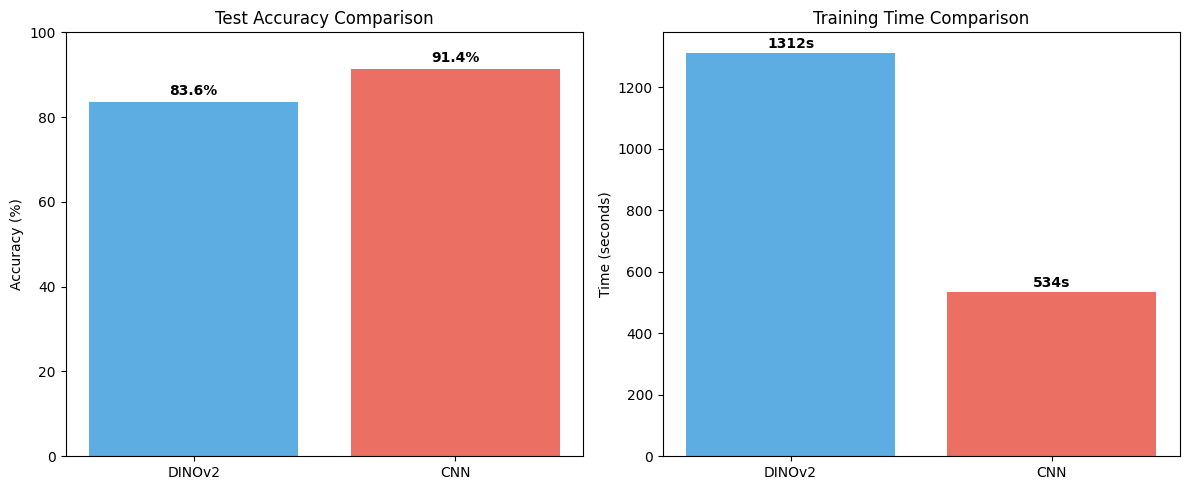

In [32]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
models = ['DINOv2', 'CNN']
test_accs = [dinov2_test_acc, cnn_test_acc]
colors = ['#3498db', '#e74c3c']

bars1 = axes[0].bar(models, test_accs, color=colors, alpha=0.8)
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])

for bar, acc in zip(bars1, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

# Training time comparison
times = [dinov2_time, cnn_time]
bars2 = axes[1].bar(models, times, color=colors, alpha=0.8)
axes[1].set_title('Training Time Comparison')
axes[1].set_ylabel('Time (seconds)')

for bar, time_val in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                f'{time_val:.0f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
# Key insights
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

accuracy_diff = dinov2_test_acc - cnn_test_acc
time_ratio = cnn_time / dinov2_time

print(f"Accuracy difference: {accuracy_diff:.1f} percentage points")
print(f"Training time ratio: {time_ratio:.1f}x")
print(f"Convergence: DINOv2 in {dinov2_epochs} epochs vs CNN in {cnn_epochs} epochs")
print(f"Parameter efficiency: DINOv2 has {dinov2_params/cnn_params:.1f}x more parameters")

if dinov2_test_acc > cnn_test_acc:
    print(f"Winner (Accuracy): DINOv2 ({dinov2_test_acc:.1f}% vs {cnn_test_acc:.1f}%)")
else:
    print(f"Winner (Accuracy): CNN ({cnn_test_acc:.1f}% vs {dinov2_test_acc:.1f}%)")

if dinov2_time < cnn_time:
    print(f"Winner (Speed): DINOv2 ({dinov2_time:.0f}s vs {cnn_time:.0f}s)")
else:
    print(f"Winner (Speed): CNN ({cnn_time:.0f}s vs {dinov2_time:.0f}s)")


KEY INSIGHTS
Accuracy difference: -7.8 percentage points
Training time ratio: 0.4x
Convergence: DINOv2 in 8 epochs vs CNN in 15 epochs
Parameter efficiency: DINOv2 has 12.7x more parameters
Winner (Accuracy): CNN (91.4% vs 83.6%)
Winner (Speed): CNN (534s vs 1312s)


## Conclusions

This comparison between DINOv2 fine-tuning and training CNN from scratch demonstrates:

### Key Findings:

- **Transfer Learning**: Pre-trained models can provide strong baselines with fewer epochs
- **Parameter Efficiency**: More parameters don't always guarantee better performance
- **Training Time**: Self-supervised models may converge faster due to good initialization
- **Data Efficiency**: Pre-trained features can work well with limited training data

### When to Choose Each Approach:

**Choose DINOv2 for**:
- Limited datasets
- Rapid prototyping
- General computer vision tasks
- Time-constrained projects

**Choose CNN from scratch for**:
- Domain-specific applications
- Large proprietary datasets
- Custom architectural requirements
- Resource-constrained environments

### Recommendations:

1. **Start with transfer learning** for most computer vision tasks
2. **Focus on data quality** over quantity
3. **Experiment with different architectures** based on your specific use case
4. **Consider computational constraints** when choosing model size